<a href="https://colab.research.google.com/github/ManLikePamo/Project/blob/main/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix as sk_confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras import callbacks
from tensorflow.keras.callbacks import Callback
%matplotlib inline

In [ ]:
import cv2
import urllib.request
import os

# ── Download OpenCV face detector models ──────────────────
def download_file(url, path):
    if not os.path.exists(path):
        print(f"Downloading {os.path.basename(path)}...")
        urllib.request.urlretrieve(url, path)
        print(f"✅ Downloaded {os.path.basename(path)}")
    else:
        print(f"✅ {os.path.basename(path)} already exists")

# OpenCV DNN face detector (more robust than Haar cascade)
FACE_PROTO = "/content/deploy.prototxt"
FACE_MODEL = "/content/res10_300x300_ssd_iter_140000.caffemodel"
# Facial landmark detector (68 points — eyes, nose, mouth)
LM_MODEL   = "/content/lbfmodel.yaml"

download_file(
    "https://raw.githubusercontent.com/opencv/opencv/master/"
    "samples/dnn/face_detector/deploy.prototxt",
    FACE_PROTO
)
download_file(
    "https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/"
    "res10_300x300_ssd_iter_140000.caffemodel",
    FACE_MODEL
)
download_file(
    "https://github.com/kurnianggoro/GSOC2017/raw/master/data/lbfmodel.yaml",
    LM_MODEL
)

# ── Load models ────────────────────────────────────────────
_face_net = cv2.dnn.readNetFromCaffe(FACE_PROTO, FACE_MODEL)
_lm_det   = cv2.face.createFacemarkLBF()
_lm_det.loadModel(LM_MODEL)

print("✅ Face detector and landmark model loaded")

# ── Alignment constants ────────────────────────────────────
_DESIRED_LEFT_EYE  = (0.25, 0.35)
_DESIRED_RIGHT_EYE = (0.75, 0.35)
_OUT_SIZE = 48


def _get_eye_centres(landmarks):
    """
    Compute left and right eye centres from 68-point landmarks.
    Points 36-41 = left eye, 42-47 = right eye (dlib convention).
    """
    left_eye  = landmarks[36:42].mean(axis=0)
    right_eye = landmarks[42:48].mean(axis=0)
    return left_eye, right_eye


def align_face_landmarks(img_gray_np: np.ndarray) -> np.ndarray:
    """
    Align a grayscale face using eye positions.
    Implements DeepFace 2D alignment (Taigman et al. 2014):
      1. Detect face with OpenCV DNN detector
      2. Find 68 facial landmarks
      3. Compute eye centres from landmark rings
      4. Apply similarity transform so eyes are at fixed positions
      5. Return 48x48 aligned float32 array

    Falls back to plain resize if detection fails.
    """
    if img_gray_np.ndim == 3:
        img_gray_np = img_gray_np[:, :, 0]

    h, w = img_gray_np.shape

    # Convert to uint8 BGR for OpenCV
    img_uint8 = (img_gray_np * 255).astype(np.uint8)
    img_bgr   = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2BGR)

    # ── Step 1: Detect face with DNN ──────────────────────
    blob = cv2.dnn.blobFromImage(
        img_bgr, 1.0, (300, 300),
        (104.0, 177.0, 123.0)
    )
    _face_net.setInput(blob)
    detections = _face_net.forward()

    face_rect = None
    best_conf = 0.0

    for i in range(detections.shape[2]):
        conf = detections[0, 0, i, 2]
        if conf > 0.4 and conf > best_conf:
            best_conf = conf
            x1 = int(detections[0, 0, i, 3] * w)
            y1 = int(detections[0, 0, i, 4] * h)
            x2 = int(detections[0, 0, i, 5] * w)
            y2 = int(detections[0, 0, i, 6] * h)
            x1 = max(0, x1); y1 = max(0, y1)
            x2 = min(w, x2); y2 = min(h, y2)
            if x2 > x1 and y2 > y1:
                face_rect = (x1, y1, x2 - x1, y2 - y1)

    if face_rect is None:
        # Fallback — treat entire image as face region
        face_rect = (0, 0, w, h)

    # ── Step 2: Detect 68 landmarks ───────────────────────
    faces_for_lm = np.array([[
        face_rect[0], face_rect[1],
        face_rect[2], face_rect[3]
    ]])

    success, landmarks = _lm_det.fit(img_bgr, faces_for_lm)

    if success and landmarks is not None and len(landmarks) > 0:
        lm_pts = landmarks[0][0]   # shape (68, 2)

        left_eye, right_eye = _get_eye_centres(lm_pts)

        # ── Step 3: Compute similarity transform ──────────
        dY    = right_eye[1] - left_eye[1]
        dX    = right_eye[0] - left_eye[0]
        angle = np.degrees(np.arctan2(dY, dX))

        desired_dist = (_DESIRED_RIGHT_EYE[0] -
                        _DESIRED_LEFT_EYE[0]) * _OUT_SIZE
        current_dist = np.sqrt(dX**2 + dY**2)
        scale        = desired_dist / current_dist if current_dist > 0 else 1.0

        eyes_mid = ((left_eye[0] + right_eye[0]) / 2,
                    (left_eye[1] + right_eye[1]) / 2)

        # ── Step 4: Apply warp ────────────────────────────
        M = cv2.getRotationMatrix2D(
            (float(eyes_mid[0]), float(eyes_mid[1])),
            angle, scale
        )
        M[0, 2] += (_OUT_SIZE * 0.5 - eyes_mid[0])
        M[1, 2] += (_OUT_SIZE * _DESIRED_LEFT_EYE[1] - eyes_mid[1])

        aligned = cv2.warpAffine(
            img_gray_np, M, (_OUT_SIZE, _OUT_SIZE),
            flags=cv2.INTER_LANCZOS4
        )
        return aligned.astype(np.float32)

    # Fallback — no landmarks, plain resize
    return cv2.resize(
        img_gray_np, (_OUT_SIZE, _OUT_SIZE),
        interpolation=cv2.INTER_LANCZOS4
    ).astype(np.float32)


def align_dataset(class_images_dict: dict, label: str = "") -> dict:
    """
    Apply align_face_landmarks to every image in a class_images dict.
    Input/output: {class_idx: np.array shape (N, 48, 48, 1)}
    """
    aligned_dict = {}
    total = sum(len(v) for v in class_images_dict.values())
    done  = 0

    for class_idx, images in class_images_dict.items():
        aligned = []
        for img in images:
            a = align_face_landmarks(img)
            aligned.append(a[:, :, np.newaxis])
            done += 1
            if done % 500 == 0:
                print(f"  {label}: {done}/{total} aligned...", end="\r")
        aligned_dict[class_idx] = np.array(aligned, dtype=np.float32)

    print(f"  {label}: {total}/{total} aligned ✅          ")
    return aligned_dict


# ── Quick check ─────────────────────────────────────
test_img = np.random.rand(48, 48).astype(np.float32)
test_out  = align_face_landmarks(test_img)
assert test_out.shape == (48, 48), "Shape mismatch!"
print(f"✅ DeepFace 2D alignment system ready (OpenCV backend)")
print(f"   Left eye target:  {_DESIRED_LEFT_EYE}")
print(f"   Right eye target: {_DESIRED_RIGHT_EYE}")
print(f"   Output size: {_OUT_SIZE}×{_OUT_SIZE}")

✅ Downloaded deploy.prototxt
✅ Downloaded res10_300x300_ssd_iter_140000.caffemodel
✅ Downloaded lbfmodel.yaml
✅ Face detector and landmark model loaded
✅ DeepFace 2D alignment system ready (OpenCV backend)
   Left eye target:  (0.25, 0.35)
   Right eye target: (0.75, 0.35)
   Output size: 48×48


In [ ]:
gpus = tf.config.experimental.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [ ]:
data_directory  = "/content/drive/MyDrive/Project/Dataset/project"
train_directory = os.path.join(data_directory, "train")
test_directory  = os.path.join(data_directory, "test")
model_directory = "/content/drive/MyDrive/Project/Dataset/model"

In [ ]:
keras_path = os.path.join(model_directory, "model.keras")
h5_path    = os.path.join(model_directory, "model.h5")

if not os.path.exists(keras_path):
    print("Migrating model from .h5 to .keras format...")
    temp_model = load_model(h5_path)
    temp_model.save(keras_path)
    del temp_model
    print(f"Migration complete. Saved to {keras_path}")
else:
    print(".keras model already exists, skipping migration.")

# Now load from the clean modern format
model = load_model(keras_path)
print("\nModel loaded successfully from .keras format.")
model.summary()


.keras model already exists, skipping migration.

Model loaded successfully from .keras format.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 46 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,890,071 (114.02 MB)

 Trainable params: 9,962,631 (38.00 MB)

 Non-trainable params: 2,176 (8.50 KB)

 Optimizer params: 19,925,264 (76.01 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("Model recompiled with fresh optimizer.")

Model recompiled with fresh optimizer.


In [ ]:
expressions_list = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

train_expression_sizes = []
for expression in expressions_list:
    expr_dir = os.path.join(train_directory, expression)
    train_expression_sizes.append(len(os.listdir(expr_dir)))

total_samples = sum(train_expression_sizes)
n_classes     = len(expressions_list)

class_weights = {}
for i, size in enumerate(train_expression_sizes):
    class_weights[i] = total_samples / (n_classes * size)

print("\nClass Weights:")
for i, expr in enumerate(expressions_list):
    print(f"  {expr:10s} → {class_weights[i]:.4f}")


Class Weights:
  angry      → 1.0266
  disgust    → 9.4066
  fear       → 1.0010
  happy      → 0.5684
  neutral    → 0.8260
  sad        → 0.8491
  surprise   → 1.2934


In [ ]:
print("\nLoading images per class...")
class_images = {}

for idx, expression in enumerate(expressions_list):
    expr_dir  = os.path.join(train_directory, expression)
    img_paths = [os.path.join(expr_dir, f) for f in os.listdir(expr_dir)]
    images    = []

    for path in img_paths:
        img = tf.keras.preprocessing.image.load_img(
            path, color_mode="grayscale", target_size=(48, 48)
        )
        img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
        images.append(img_array)

    class_images[idx] = np.array(images)
    print(f"  {expression:10s} → {len(images)} images loaded")

print("All images loaded.")



Loading images per class...
  angry      → 3995 images loaded
  disgust    → 436 images loaded
  fear       → 4097 images loaded
  happy      → 7215 images loaded
  neutral    → 4965 images loaded
  sad        → 4830 images loaded
  surprise   → 3171 images loaded
All images loaded.


In [ ]:
print("Aligning FER2013 training images...")
class_images = align_dataset(class_images, label="FER2013 train")
print("✅ class_images now contains aligned faces.")

Aligning FER2013 training images...
  FER2013 train: 28709/28709 aligned ✅          
✅ class_images now contains aligned faces.


In [ ]:
def augment_image(image):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image.numpy()

In [ ]:
def balanced_batch_generator(class_images, batch_size=64, augment=True):
    """
    Generates balanced batches where each emotion class
    contributes equally to every batch.

    Args:
        class_images (dict) : Dictionary of {class_idx: np.array of images}
        batch_size   (int)  : Total batch size. Divided equally across classes.
        augment      (bool) : Whether to apply augmentation.

    Yields:
        (images, labels) : Balanced batch as numpy arrays.
    """
    n_classes        = len(class_images)
    samples_per_class = batch_size // n_classes  # e.g. 64 // 7 = 9 per class

    while True:
        batch_images = []
        batch_labels = []

        for class_idx in range(n_classes):
            # Sample with replacement — this is the oversampling step
            # for minority classes like disgust (only 436 images)
            indices = np.random.choice(
                len(class_images[class_idx]),
                size=samples_per_class,
                replace=True   # allows oversampling when class is small
            )
            selected = class_images[class_idx][indices]

            if augment:
                selected = np.array([augment_image(img) for img in selected])

            batch_images.append(selected)
            batch_labels.extend([class_idx] * samples_per_class)

        batch_images = np.concatenate(batch_images, axis=0)
        batch_labels = np.array(batch_labels)

        # Shuffle within batch so class order is randomised
        shuffle_idx  = np.random.permutation(len(batch_labels))
        batch_images = batch_images[shuffle_idx]
        batch_labels = batch_labels[shuffle_idx]

        yield batch_images, batch_labels

In [ ]:
NEW_BATCH = 63  # divisible by 7 (9 per class exactly)

new_output_sig = (
    tf.TensorSpec(shape=(NEW_BATCH, 48, 48, 1), dtype=tf.float32),
    tf.TensorSpec(shape=(NEW_BATCH,),            dtype=tf.int32)
)

new_balanced_train = tf.data.Dataset.from_generator(
    lambda: balanced_batch_generator_v2(
        new_train_class_images, batch_size=NEW_BATCH,
        augment=True,
        weak_classes=[0, 2]   # angry=0, fear=2
    ),
    output_signature=new_output_sig
).prefetch(tf.data.AUTOTUNE)

In [ ]:
data = tf.keras.preprocessing.image_dataset_from_directory(
    train_directory,
    image_size=(48, 48),
    batch_size=64,
    color_mode="grayscale",
    seed=42
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_directory,
    image_size=(48, 48),
    batch_size=64,
    color_mode="grayscale",
    shuffle=False,
    seed=42
)

data      = data.map(lambda x, y: (x / 255., y)).cache()
data      = data.prefetch(tf.data.AUTOTUNE)
test_data = test_data.map(lambda x, y: (x / 255., y))

train_size      = int(len(data) * 0.875)
validation_size = int(len(data) * 0.125)

validation = data.skip(train_size).take(validation_size)

print(f"Validation batches: {validation_size}")

print("\nBuilding balanced validation set from loaded images...")
val_class_images   = {}
train_class_images = {}

for idx, expression in enumerate(expressions_list):
    total_imgs = class_images[idx]
    split_idx  = int(len(total_imgs) * 0.875)

    train_class_images[idx] = total_imgs[:split_idx]
    val_class_images[idx]   = total_imgs[split_idx:]
    print(f"  {expression:10s} \u2192 "
          f"train: {len(train_class_images[idx])} | "
          f"val: {len(val_class_images[idx])}")

# Replace class_images with the training-only split
class_images = train_class_images

VAL_BATCH_SIZE = 63

val_output_signature = (
    tf.TensorSpec(shape=(VAL_BATCH_SIZE, 48, 48, 1), dtype=tf.float32),
    tf.TensorSpec(shape=(VAL_BATCH_SIZE,),            dtype=tf.int32)
)

balanced_val_dataset = tf.data.Dataset.from_generator(
    lambda: balanced_batch_generator(
        val_class_images, batch_size=VAL_BATCH_SIZE, augment=False
    ),
    output_signature=val_output_signature
).take(56)

print("Balanced validation dataset ready.")

# Define balanced_train_dataset for the first training phase
TRAIN_BATCH_SIZE = 63
train_output_signature = (
    tf.TensorSpec(shape=(TRAIN_BATCH_SIZE, 48, 48, 1), dtype=tf.float32),
    tf.TensorSpec(shape=(TRAIN_BATCH_SIZE,),            dtype=tf.int32)
)

balanced_train_dataset = tf.data.Dataset.from_generator(
    lambda: balanced_batch_generator(
        class_images, batch_size=TRAIN_BATCH_SIZE, augment=True
    ),
    output_signature=train_output_signature
).prefetch(tf.data.AUTOTUNE)

print("Balanced training dataset ready.")

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
Validation batches: 56

Building balanced validation set from loaded images...
  angry      → train: 3495 | val: 500
  disgust    → train: 381 | val: 55
  fear       → train: 3584 | val: 513
  happy      → train: 6313 | val: 902
  neutral    → train: 4344 | val: 621
  sad        → train: 4226 | val: 604
  surprise   → train: 2774 | val: 397
Balanced validation dataset ready.
Balanced training dataset ready.


In [ ]:
steps_per_epoch  = 600   # increased from 392 — more steps per epoch
validation_steps = 56

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
def augment_image_strong(image):
    """
    Stronger augmentation for weak emotion classes.
    Applied to angry and fear which have the lowest accuracy.
    Includes additional rotation simulation via shear and
    stronger brightness/contrast shifts.
    """
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)   # stronger
    image = tf.image.random_contrast(image, lower=0.7, upper=1.3)  # stronger
    # Simulate slight head tilt by cropping and resizing
    image = tf.image.random_crop(image, size=[42, 42, 1])
    image = tf.image.resize(image, [48, 48])
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image.numpy()


def balanced_batch_generator_v2(class_images, batch_size=63,
                                 augment=True,
                                 weak_classes=[0, 2]):
    """
    Improved balanced batch generator that applies stronger
    augmentation to weak performing classes (angry=0, fear=2)
    while using standard augmentation for the rest.

    Args:
        class_images  (dict) : {class_idx: np.array of images}
        batch_size    (int)  : Total batch size, divisible by 7.
        augment       (bool) : Whether to apply augmentation.
        weak_classes  (list) : Class indices to apply stronger
                               augmentation to. Default angry(0)
                               and fear(2).
    Yields:
        (images, labels)     : Balanced and shuffled batch.
    """
    n_classes         = len(class_images)
    samples_per_class = batch_size // n_classes

    while True:
        batch_images = []
        batch_labels = []

        for class_idx in range(n_classes):
            indices  = np.random.choice(
                len(class_images[class_idx]),
                size=samples_per_class,
                replace=True
            )
            selected = class_images[class_idx][indices]

            if augment:
                if class_idx in weak_classes:
                    # Stronger augmentation for weak classes
                    selected = np.array([
                        augment_image_strong(img) for img in selected
                    ])
                else:
                    # Standard augmentation for other classes
                    selected = np.array([
                        augment_image(img) for img in selected
                    ])

            batch_images.append(selected)
            batch_labels.extend([class_idx] * samples_per_class)

        batch_images = np.concatenate(batch_images, axis=0)
        batch_labels = np.array(batch_labels)

        shuffle_idx  = np.random.permutation(len(batch_labels))
        batch_images = batch_images[shuffle_idx]
        batch_labels = batch_labels[shuffle_idx]

        yield batch_images, batch_labels

In [ ]:
class TrainingCallbacks(Callback):
    def __init__(self):
        self.start_time = None

    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print("Resuming training with balanced batches ...")

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.start_time
        print(f"Epoch {epoch+1} | "
              f"acc: {logs['accuracy']:.4f} | "
              f"val_acc: {logs['val_accuracy']:.4f} | "
              f"time: {elapsed:.1f}s")

    def on_train_end(self, logs=None):
        total = time.time() - self.start_time
        print(f"Training finished in {total:.1f} seconds")


checkpoint = callbacks.ModelCheckpoint(
    filepath=os.path.join(
        "/content/drive/MyDrive/Project/Dataset/model", "model_Improved.keras"
    ),
    save_best_only=True,
    monitor="val_accuracy",
    verbose=1
)

early_stopping = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=15,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-8,
    verbose=1
)

callbacks_list = [TrainingCallbacks(), checkpoint, early_stopping, reduce_lr]


In [ ]:
history = model.fit(
    balanced_train_dataset,
    epochs=60,
    steps_per_epoch=steps_per_epoch,
    validation_data=balanced_val_dataset,
    validation_steps=56,
    callbacks=callbacks_list,
    class_weight=class_weights,
    verbose=1
)

if not isinstance(history, dict):
    history = history.history

os.makedirs("history", exist_ok=True)
with open(os.path.join("history", "improved_history2.pkl"), "wb") as f:
    pickle.dump(history, f)


Resuming training with balanced batches ...
Epoch 1/60
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.3444 - loss: 11.4200Epoch 1 | acc: 0.3670 | val_acc: 0.4544 | time: 95.7s

Epoch 1: val_accuracy improved from None to 0.45437, saving model to /content/drive/MyDrive/Project/Dataset/model/model_Improved.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Project/Dataset/model/model_Improved.keras
600/600 ━━━━━━━━━━━━━━━━━━━━ 103s 151ms/step - accuracy: 0.3670 - loss: 9.2200 - val_accuracy: 0.4544 - val_loss: 3.1160 - learning_rate: 1.0000e-05
Epoch 2/60
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.4131 - loss: 5.4644Epoch 2 | acc: 0.4168 | val_acc: 0.4518 | time: 184.4s

Epoch 2: val_accuracy did not improve from 0.45437
600/600 ━━━━━━━━━━━━━━━━━━━━ 82s 136ms/step - accuracy: 0.4168 - loss: 4.9996 - val_accuracy: 0.4518 - val_loss: 2.7615 - learning_rate: 1.0000e-05
Epoch 3/60
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.4355 - loss: 3.827

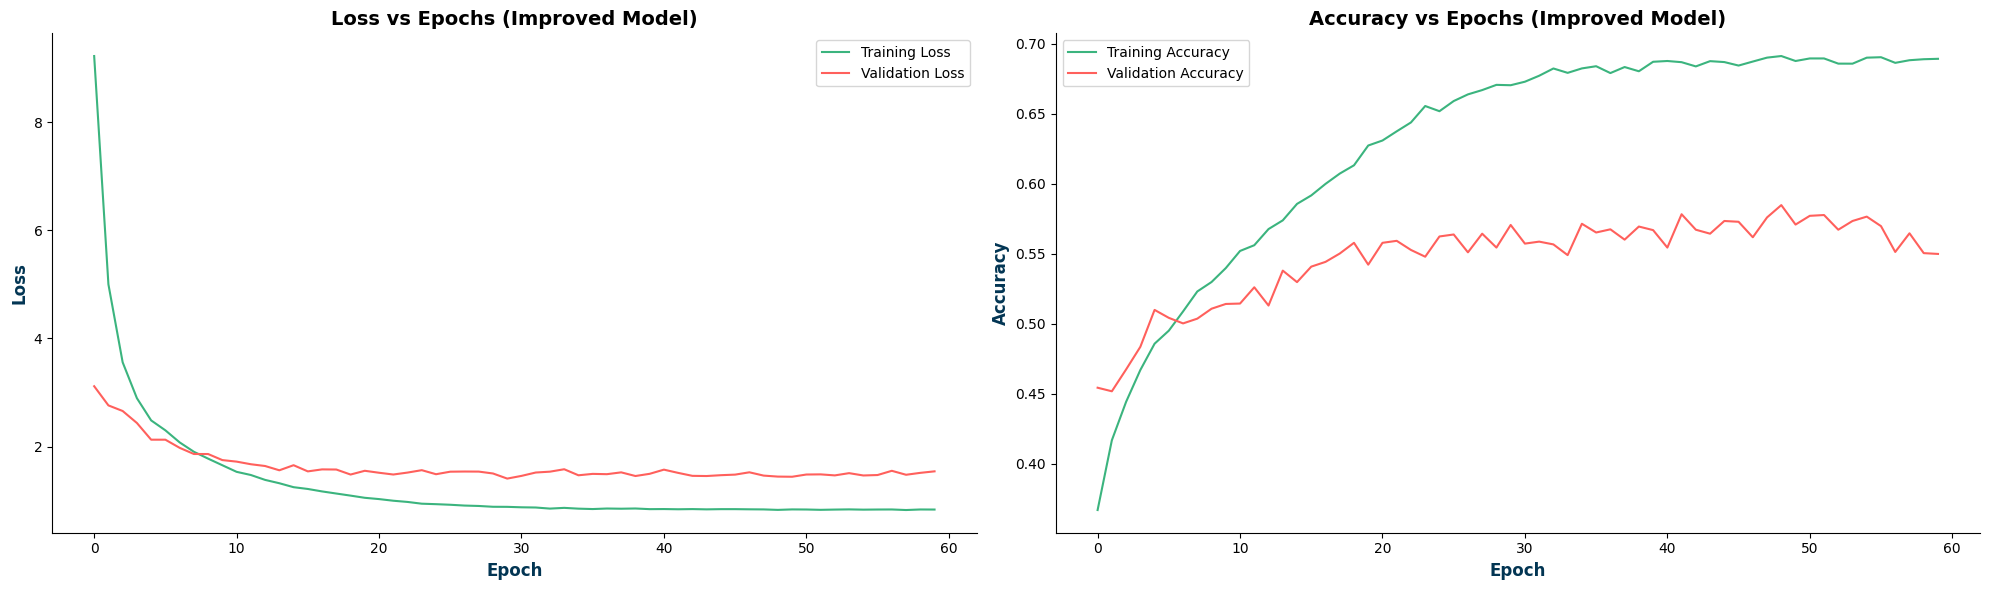

In [ ]:
title_font = {"color": "k",       "weight": "bold", "size": 14}
axes_font  = {"color": "#023553", "weight": "bold", "size": 12}

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

axes[0].plot(history["loss"],     color="#3BB47E", label="Training Loss")
axes[0].plot(history["val_loss"], color="#FF605C", label="Validation Loss")
axes[0].set_title("Loss vs Epochs (Improved Model)", fontdict=title_font)
axes[0].set_xlabel("Epoch", fontdict=axes_font)
axes[0].set_ylabel("Loss", fontdict=axes_font)
axes[0].legend()
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].plot(history["accuracy"],     color="#3BB47E", label="Training Accuracy")
axes[1].plot(history["val_accuracy"], color="#FF605C", label="Validation Accuracy")
axes[1].set_title("Accuracy vs Epochs (Improved Model)", fontdict=title_font)
axes[1].set_xlabel("Epoch", fontdict=axes_font)
axes[1].set_ylabel("Accuracy", fontdict=axes_font)
axes[1].legend()
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [33]:
print("\n" + "="*60)
print("TEST SET EVALUATION")
print("="*60)

test_loss, test_accuracy = model.evaluate(test_data, verbose=1)
print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")


TEST SET EVALUATION
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.4791 - loss: 0.3093

Test Accuracy: 47.91%
Test Loss:     0.3093


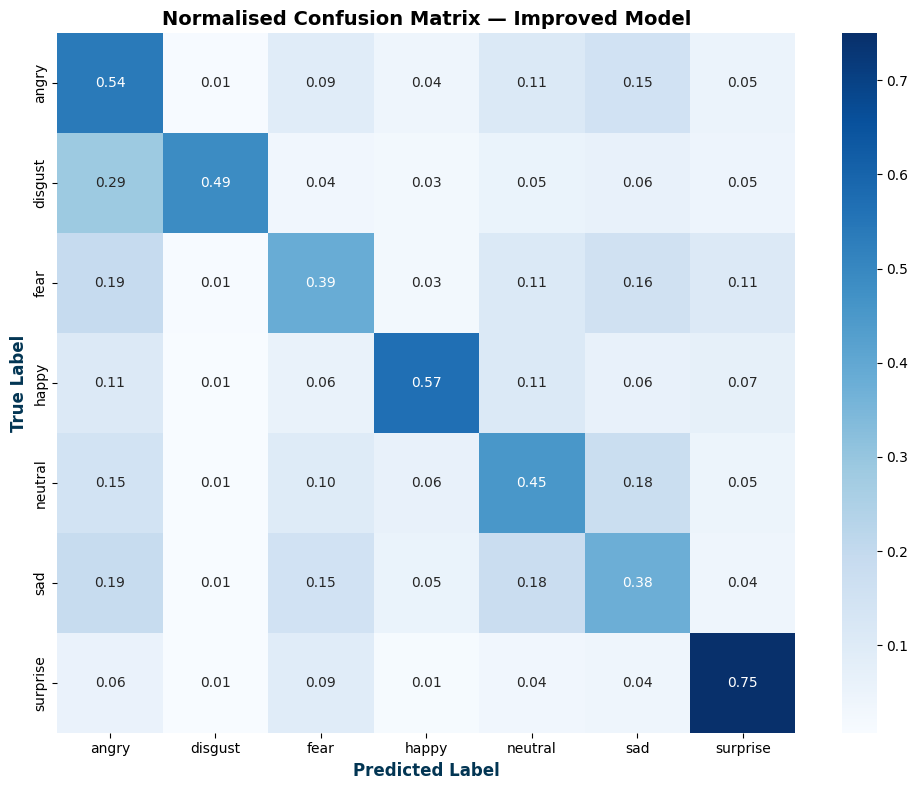

In [ ]:
y_true = []
y_pred = []

for images, labels in test_data:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm            = sk_confusion_matrix(y_true, y_pred)
cm_normalised = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_normalised,
            annot=True,
            fmt=".2f",
            cmap="Blues",
            xticklabels=expressions_list,
            yticklabels=expressions_list,
            ax=ax)
ax.set_title("Normalised Confusion Matrix — Improved Model", fontdict=title_font)
ax.set_xlabel("Predicted Label", fontdict=axes_font)
ax.set_ylabel("True Label", fontdict=axes_font)
plt.tight_layout()
plt.show()


PER EMOTION ACCURACY
 Emotion  Correct  Total  Accuracy %
surprise      623    831       74.97
   happy     1008   1774       56.82
   angry      518    958       54.07
 disgust       54    111       48.65
 neutral      560   1233       45.42
    fear      396   1024       38.67
     sad      471   1247       37.77


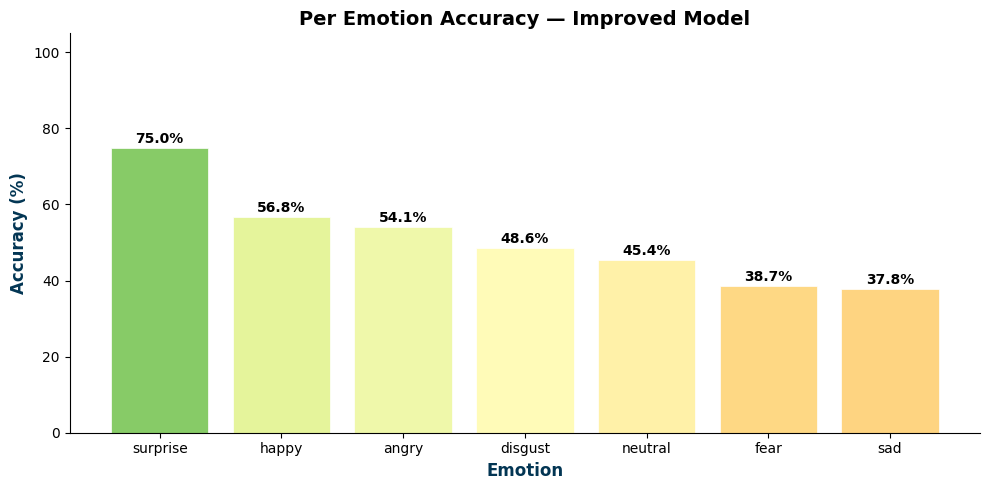

In [ ]:
print("\n" + "="*60)
print("PER EMOTION ACCURACY")
print("="*60)

per_emotion_accuracy = cm_normalised.diagonal()

per_emotion_df = pd.DataFrame({
    "Emotion":    expressions_list,
    "Correct":    cm.diagonal(),
    "Total":      cm.sum(axis=1),
    "Accuracy %": (per_emotion_accuracy * 100).round(2)
}).sort_values("Accuracy %", ascending=False)

print(per_emotion_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.RdYlGn(per_emotion_df["Accuracy %"].values / 100)
bars   = ax.bar(per_emotion_df["Emotion"],
                per_emotion_df["Accuracy %"],
                color=colors, edgecolor="white", linewidth=0.5)

for bar, val in zip(bars, per_emotion_df["Accuracy %"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val:.1f}%",
            ha="center", va="bottom",
            fontweight="bold", fontsize=10)

ax.set_title("Per Emotion Accuracy — Improved Model", fontdict=title_font)
ax.set_xlabel("Emotion", fontdict=axes_font)
ax.set_ylabel("Accuracy (%)", fontdict=axes_font)
ax.set_ylim(0, 105)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=expressions_list))


Classification Report:
              precision    recall  f1-score   support

       angry       0.37      0.54      0.44       958
     disgust       0.45      0.49      0.47       111
        fear       0.40      0.39      0.39      1024
       happy       0.82      0.57      0.67      1774
     neutral       0.45      0.45      0.45      1233
         sad       0.41      0.38      0.39      1247
    surprise       0.60      0.75      0.67       831

    accuracy                           0.51      7178
   macro avg       0.50      0.51      0.50      7178
weighted avg       0.53      0.51      0.51      7178



In [ ]:
new_data_directory = "/content/drive/MyDrive/Project/Dataset/processed_data"

print("Loading new dataset images per class...")

new_train_class_images = {}
new_val_class_images   = {}
new_test_class_images  = {}
new_train_sizes        = []

for idx, expression in enumerate(expressions_list):
    expr_dir  = os.path.join(new_data_directory, expression)
    img_paths = sorted([
        os.path.join(expr_dir, f)
        for f in os.listdir(expr_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    images = []
    for path in img_paths:
        img = tf.keras.preprocessing.image.load_img(
            path,
            color_mode="grayscale",
            target_size=(48, 48)    # resize from 96x96 to 48x48
        )
        img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
        images.append(img_array)

    images    = np.array(images)
    n         = len(images)
    train_end = int(n * 0.80)
    val_end   = int(n * 0.90)

    new_train_class_images[idx] = images[:train_end]
    new_val_class_images[idx]   = images[train_end:val_end]
    new_test_class_images[idx]  = images[val_end:]
    new_train_sizes.append(len(new_train_class_images[idx]))

    print(f"  {expression:10s} → "
          f"total: {n} | "
          f"train: {len(new_train_class_images[idx])} | "
          f"val: {len(new_val_class_images[idx])} | "
          f"test: {len(new_test_class_images[idx])}")

print("\nAll new dataset images loaded and split.")

Loading new dataset images per class...
  angry      → total: 5920 | train: 4736 | val: 592 | test: 592
  disgust    → total: 5920 | train: 4736 | val: 592 | test: 592
  fear       → total: 5920 | train: 4736 | val: 592 | test: 592
  happy      → total: 11398 | train: 9118 | val: 1140 | test: 1140
  neutral    → total: 8166 | train: 6532 | val: 817 | test: 817
  sad        → total: 6535 | train: 5228 | val: 653 | test: 654
  surprise   → total: 5920 | train: 4736 | val: 592 | test: 592

All new dataset images loaded and split.


In [ ]:
print("Aligning new dataset images...")
new_train_class_images = align_dataset(new_train_class_images, label="new train")
new_val_class_images   = align_dataset(new_val_class_images,   label="new val")
new_test_class_images  = align_dataset(new_test_class_images,  label="new test")
print("✅ New dataset alignment complete.")

Aligning new dataset images...
  new train: 39822/39822 aligned ✅          
  new val: 4978/4978 aligned ✅          
  new test: 4979/4979 aligned ✅          
✅ New dataset alignment complete.


In [ ]:
new_total     = sum(new_train_sizes)
new_n_classes = len(expressions_list)

new_class_weights = {}
for i, size in enumerate(new_train_sizes):
    new_class_weights[i] = new_total / (new_n_classes * size)

print("New Dataset Class Weights:")
for i, expr in enumerate(expressions_list):
    print(f"  {expr:10s} → {new_class_weights[i]:.4f}")

new_class_weights[0] = new_class_weights[0] * 2.5  # angry index is 0
print(f"\nAdjusted angry class weight: {new_class_weights[0]:.4f}")
print("(doubled to combat disgust/angry confusion)")

New Dataset Class Weights:
  angry      → 1.2012
  disgust    → 1.2012
  fear       → 1.2012
  happy      → 0.6239
  neutral    → 0.8709
  sad        → 1.0882
  surprise   → 1.2012

Adjusted angry class weight: 3.0030
(doubled to combat disgust/angry confusion)


In [ ]:
NEW_BATCH = 63

new_output_sig = (
    tf.TensorSpec(shape=(NEW_BATCH, 48, 48, 1), dtype=tf.float32),
    tf.TensorSpec(shape=(NEW_BATCH,),            dtype=tf.int32)
)

new_balanced_train = tf.data.Dataset.from_generator(
    lambda: balanced_batch_generator(
        new_train_class_images, batch_size=NEW_BATCH, augment=True
    ),
    output_signature=new_output_sig
).prefetch(tf.data.AUTOTUNE)

new_balanced_val = tf.data.Dataset.from_generator(
    lambda: balanced_batch_generator(
        new_val_class_images, batch_size=NEW_BATCH, augment=False
    ),
    output_signature=new_output_sig
).take(56)

print("New dataset generators ready.")

New dataset generators ready.


In [ ]:
def focal_loss(gamma=2.0, alpha=0.25):
    """
    Focal loss for multi-class classification.
    Reduces the loss contribution of easy examples so the
    model focuses on hard misclassified ones.

    Args:
        gamma (float) : Focusing parameter. 0 = standard
                        cross-entropy. 2.0 is standard default.
        alpha (float) : Weighting factor for rare classes.

    Returns:
        loss function compatible with model.compile()
    """
    def loss_fn(y_true, y_pred):
        y_true    = tf.cast(y_true, tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=7)
        y_pred    = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # Cross entropy
        ce = -tf.reduce_sum(y_true_oh * tf.math.log(y_pred), axis=-1)

        # Probability of the true class
        pt = tf.reduce_sum(y_true_oh * y_pred, axis=-1)

        # Focal weight — down-weights easy correct predictions
        focal_weight = alpha * tf.pow(1.0 - pt, gamma)

        return tf.reduce_mean(focal_weight * ce)

    return loss_fn

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=["accuracy"]
)

new_steps_per_epoch  = 600
new_validation_steps = 56

new_checkpoint = callbacks.ModelCheckpoint(
    filepath=os.path.join(model_directory, "model_improved.keras"),
    save_best_only=True,
    monitor="val_accuracy",
    verbose=1
)

new_early_stopping = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=15,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

new_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-8,
    verbose=1
)

new_callbacks_list = [
    TrainingCallbacks(),
    new_checkpoint,
    new_early_stopping,
    new_reduce_lr
]

print("Starting continued training on new dataset...")
print("="*60)

new_history = model.fit(
    new_balanced_train,
    epochs=60,
    steps_per_epoch=new_steps_per_epoch,
    validation_data=new_balanced_val,
    validation_steps=new_validation_steps,
    callbacks=new_callbacks_list,
    class_weight=new_class_weights,
    verbose=1
)

if not isinstance(new_history, dict):
    new_history = new_history.history

with open(os.path.join("history", "new_dataset_history.pkl"), "wb") as f:
    pickle.dump(new_history, f)

print("Training on new dataset complete.")

Starting continued training on new dataset...
Resuming training with balanced batches ...
Epoch 1/60
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.4979 - loss: 0.5594Epoch 1 | acc: 0.5084 | val_acc: 0.5054 | time: 91.4s

Epoch 1: val_accuracy improved from None to 0.50539, saving model to /content/drive/MyDrive/Project/Dataset/model/model_improved.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Project/Dataset/model/model_improved.keras
600/600 ━━━━━━━━━━━━━━━━━━━━ 97s 148ms/step - accuracy: 0.5084 - loss: 0.5243 - val_accuracy: 0.5054 - val_loss: 0.5024 - learning_rate: 1.0000e-05
Epoch 2/60
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.5240 - loss: 0.4622Epoch 2 | acc: 0.5292 | val_acc: 0.5383 | time: 179.1s

Epoch 2: val_accuracy improved from 0.50539 to 0.53827, saving model to /content/drive/MyDrive/Project/Dataset/model/model_improved.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Project/Dataset/model/model_improved.keras
60


NEW DATASET — TEST SET EVALUATION

Test Accuracy (New Dataset): 62.66%


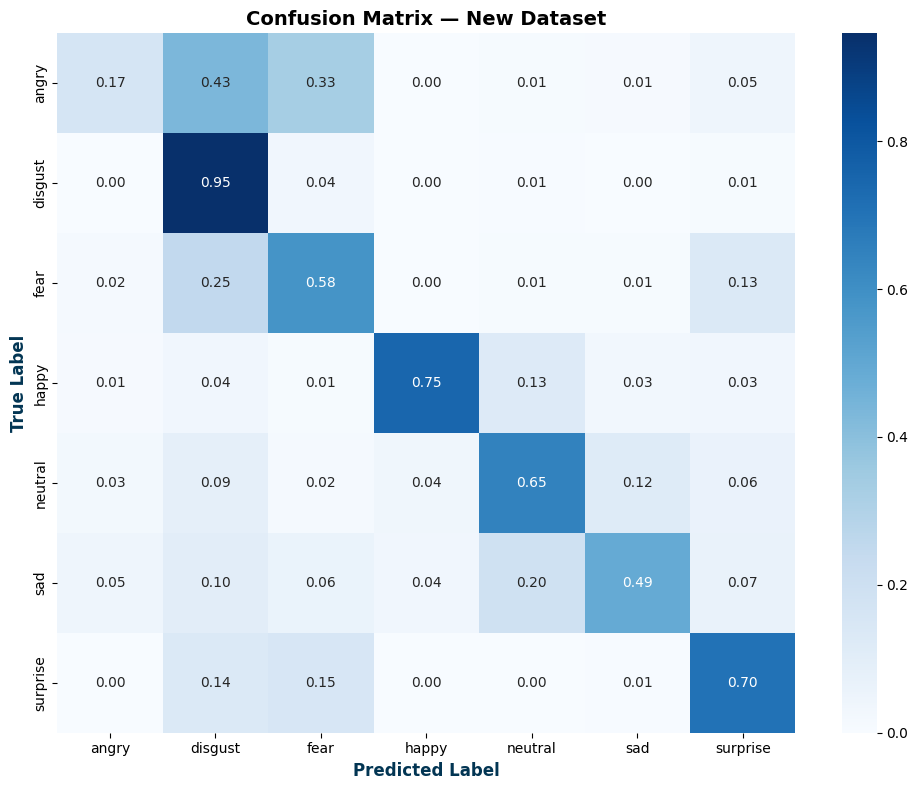


Per Emotion Accuracy (New Dataset):
 Emotion  Correct  Total  Accuracy %
 disgust      560    592       94.59
   happy      854   1140       74.91
surprise      416    592       70.27
 neutral      529    817       64.75
    fear      344    592       58.11
     sad      319    654       48.78
   angry       98    592       16.55


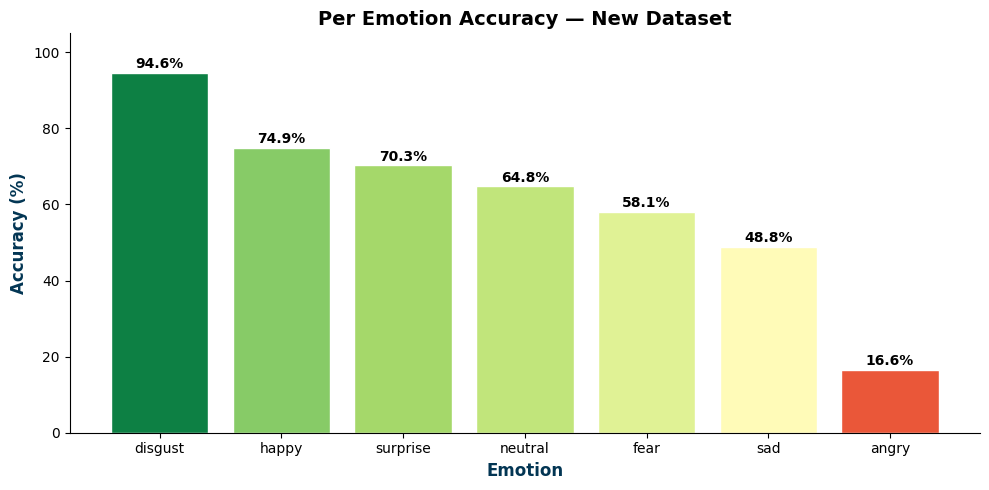


Classification Report (New Dataset):
              precision    recall  f1-score   support

       angry       0.55      0.17      0.25       592
     disgust       0.46      0.95      0.62       592
        fear       0.48      0.58      0.53       592
       happy       0.94      0.75      0.83      1140
     neutral       0.65      0.65      0.65       817
         sad       0.68      0.49      0.57       654
    surprise       0.63      0.70      0.66       592

    accuracy                           0.63      4979
   macro avg       0.63      0.61      0.59      4979
weighted avg       0.66      0.63      0.62      4979



In [ ]:
print("\n" + "="*60)
print("NEW DATASET — TEST SET EVALUATION")
print("="*60)

new_y_true = []
new_y_pred = []

for class_idx in range(new_n_classes):
    test_imgs = new_test_class_images[class_idx]
    if len(test_imgs) == 0:
        continue
    preds = model.predict(test_imgs, verbose=0)
    new_y_pred.extend(np.argmax(preds, axis=1))
    new_y_true.extend([class_idx] * len(test_imgs))

new_y_true = np.array(new_y_true)
new_y_pred = np.array(new_y_pred)

new_test_accuracy = np.mean(new_y_true == new_y_pred)
print(f"\nTest Accuracy (New Dataset): {new_test_accuracy * 100:.2f}%")

# Confusion matrix
new_cm            = sk_confusion_matrix(new_y_true, new_y_pred)
new_cm_normalised = new_cm.astype("float") / new_cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(new_cm_normalised,
            annot=True,
            fmt=".2f",
            cmap="Blues",
            xticklabels=expressions_list,
            yticklabels=expressions_list,
            ax=ax)
ax.set_title("Confusion Matrix — New Dataset", fontdict=title_font)
ax.set_xlabel("Predicted Label", fontdict=axes_font)
ax.set_ylabel("True Label",      fontdict=axes_font)
plt.tight_layout()
plt.show()

# Per emotion accuracy
new_per_emotion    = new_cm_normalised.diagonal()
new_per_emotion_df = pd.DataFrame({
    "Emotion":    expressions_list,
    "Correct":    new_cm.diagonal(),
    "Total":      new_cm.sum(axis=1),
    "Accuracy %": (new_per_emotion * 100).round(2)
}).sort_values("Accuracy %", ascending=False)

print("\nPer Emotion Accuracy (New Dataset):")
print(new_per_emotion_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.RdYlGn(new_per_emotion_df["Accuracy %"].values / 100)
bars   = ax.bar(new_per_emotion_df["Emotion"],
                new_per_emotion_df["Accuracy %"],
                color=colors, edgecolor="white")

for bar, val in zip(bars, new_per_emotion_df["Accuracy %"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val:.1f}%",
            ha="center", va="bottom",
            fontweight="bold", fontsize=10)

ax.set_title("Per Emotion Accuracy — New Dataset", fontdict=title_font)
ax.set_xlabel("Emotion",      fontdict=axes_font)
ax.set_ylabel("Accuracy (%)", fontdict=axes_font)
ax.set_ylim(0, 105)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print("\nClassification Report (New Dataset):")
print(classification_report(new_y_true, new_y_pred,
                            target_names=expressions_list))